# ✈️ Airline Passenger Satisfaction Prediction

## 04. Artificial Neural Network Model

This notebook develops, trains, and saves an Artificial Neural Network for predicting airline passenger satisfaction.

The workflow includes:

- Loading processed data
- Setting reproducibility
- Building the ANN architecture
- Compiling the model
- Training with validation data
- Early stopping
- Learning-rate reduction
- Visualizing training performance
- Saving the trained ANN model
- Saving the training history

In [1]:
# Step 2 : Importing Libraries

import os
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

In [2]:
# Step 3 : Setting Random Seeds

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [3]:
# Step 4 : Checking TensorFlow Version

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [4]:
# Step 5 : Loading Processed Data

X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")

X_val = np.load("../data/processed/X_val.npy")
y_val = np.load("../data/processed/y_val.npy")

X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")

print("Training Features:", X_train.shape)
print("Training Target:", y_train.shape)

print("Validation Features:", X_val.shape)
print("Validation Target:", y_val.shape)

print("Testing Features:", X_test.shape)
print("Testing Target:", y_test.shape)

Training Features: (83123, 27)
Training Target: (83123,)
Validation Features: (20781, 27)
Validation Target: (20781,)
Testing Features: (25976, 27)
Testing Target: (25976,)


In [5]:
# Step 6 : Defining ANN Input Size

input_features = X_train.shape[1]

print("Number of Input Features:", input_features)

Number of Input Features: 27


In [6]:
# Step 7 : Checking Target Values

print("Unique Training Target Values:")
print(np.unique(y_train))

print("\nUnique Validation Target Values:")
print(np.unique(y_val))

Unique Training Target Values:
[0. 1.]

Unique Validation Target Values:
[0. 1.]


In [7]:
# Step 8 : Creating Models Folder

os.makedirs("../models", exist_ok=True)

print("Models folder is ready.")

Models folder is ready.


In [8]:
# Step 9 : Building the ANN Architecture

model = Sequential([
    
    Dense(
        64,
        activation="relu",
        input_shape=(input_features,)
    ),
    
    Dropout(0.30),
    
    Dense(
        32,
        activation="relu"
    ),
    
    Dropout(0.20),
    
    Dense(
        16,
        activation="relu"
    ),
    
    Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

c:\Users\dhanu\Desktop\airline-ann\.myenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Step 10 : Compiling the ANN

optimizer = Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=[
        "accuracy"
    ]
)

print("ANN compiled successfully.")

ANN compiled successfully.


In [10]:
# Step 11 : Creating Early Stopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [11]:
# Step 12 : Creating Learning Rate Reduction

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

In [12]:
# Step 13 : Creating Model Checkpoint

checkpoint_path = "../models/best_airline_satisfaction_ann.keras"

model_checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Best model will be saved to:")
print(checkpoint_path)

Best model will be saved to:
../models/best_airline_satisfaction_ann.keras


In [13]:
# Step 14 : Training the ANN

BATCH_SIZE = 32
EPOCHS = 50

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ],
    shuffle=True,
    verbose=1
)

Epoch 1/50
2563/2598 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - accuracy: 0.8994 - loss: 0.2526
Epoch 1: val_loss improved from None to 0.14587, saving model to ../models/best_airline_satisfaction_ann.keras

Epoch 1: finished saving model to ../models/best_airline_satisfaction_ann.keras
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8998 - loss: 0.2517 - val_accuracy: 0.9424 - val_loss: 0.1459 - learning_rate: 0.0010
Epoch 2/50
2588/2598 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9349 - loss: 0.1583
Epoch 2: val_loss improved from 0.14587 to 0.12127, saving model to ../models/best_airline_satisfaction_ann.keras

Epoch 2: finished saving model to ../models/best_airline_satisfaction_ann.keras
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9349 - loss: 0.1583 - val_accuracy: 0.9500 - val_loss: 0.1213 - learning_rate: 0.0010
Epoch 3/50
2578/2598 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9437 - loss: 0.1373
Epoch 3: val_loss improved from 0.12127 to 0.11483, saving mo

In [14]:
# Step 15 : Checking Training Epochs

trained_epochs = len(history.history["loss"])

print("Total Epochs Actually Trained:", trained_epochs)

Total Epochs Actually Trained: 44


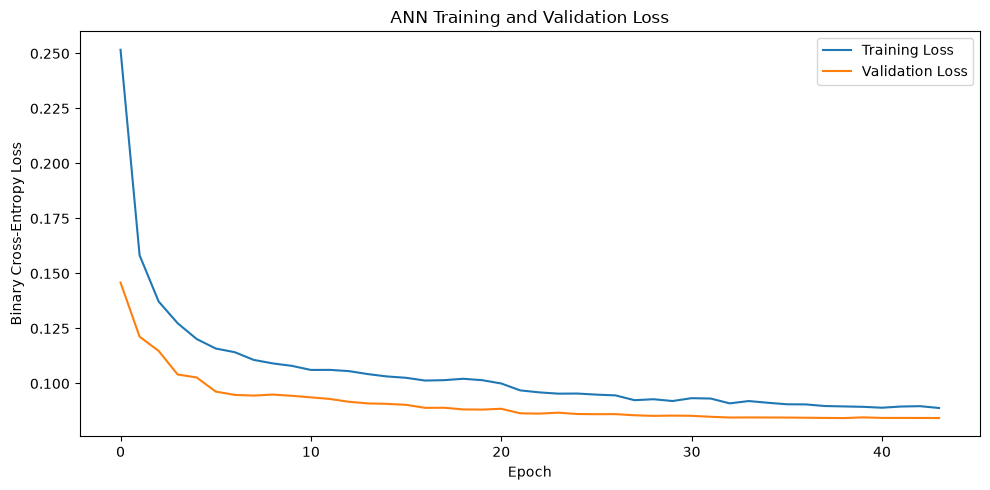

In [15]:
# Step 16 : Plotting Training and Validation Loss

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()

plt.tight_layout()
plt.show()

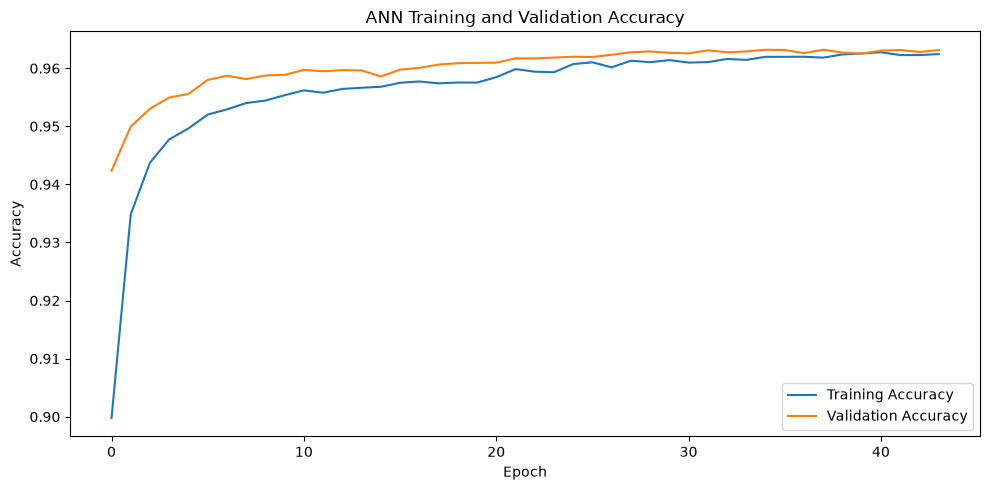

In [16]:
# Step 17 : Plotting Training and Validation Accuracy

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
# Step 18 : Creating Training History DataFrame

history_df = pd.DataFrame(history.history)

history_df.index = history_df.index + 1

history_df.index.name = "Epoch"

history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
Epoch,,,,,
1,0.899751,0.251673,0.942351,0.145874,0.001000
2,0.934856,0.158307,0.949954,0.121273,0.001000
3,0.943746,0.137281,0.953034,0.114830,0.001000
4,0.947752,0.127376,0.954959,0.104075,0.001000
5,0.949641,0.120202,0.955584,0.102739,0.001000
6,0.952023,0.115888,0.957990,0.096321,0.001000
7,0.952913,0.114224,0.958712,0.094809,0.001000
8,0.954008,0.110704,0.958135,0.094499,0.001000
9,0.954441,0.109121,0.958760,0.094964,0.001000


In [18]:
# Step 19 : Displaying Best Validation Performance

best_epoch = history_df["val_loss"].idxmin()

best_val_loss = history_df.loc[
    best_epoch,
    "val_loss"
]

best_val_accuracy = history_df.loc[
    best_epoch,
    "val_accuracy"
]

print("Best Epoch:", best_epoch)
print("Best Validation Loss:", round(best_val_loss, 4))
print("Validation Accuracy at Best Epoch:", round(best_val_accuracy, 4))

Best Epoch: 39
Best Validation Loss: 0.0843
Validation Accuracy at Best Epoch: 0.9627


In [19]:
# Step 20 : Loading the Best Saved Model

best_model = tf.keras.models.load_model(
    "../models/best_airline_satisfaction_ann.keras"
)

print("Best ANN model loaded successfully.")

Best ANN model loaded successfully.


In [20]:
# Step 21 : Evaluating the ANN on Validation Data

val_loss, val_accuracy = best_model.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("Validation Loss:", round(val_loss, 4))
print("Validation Accuracy:", round(val_accuracy, 4))

Validation Loss: 0.0843
Validation Accuracy: 0.9627


In [21]:
# Step 22 : Generating Test Predictions

test_probabilities = best_model.predict(
    X_test,
    verbose=0
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

print("Test Predictions Generated.")

print("\nFirst 10 Probabilities:")
print(test_probabilities[:10])

print("\nFirst 10 Predictions:")
print(test_predictions[:10])

Test Predictions Generated.

First 10 Probabilities:
[9.9072820e-01 1.0000000e+00 7.7652902e-04 1.0000000e+00 2.2442991e-01
 9.9896383e-01 9.9999881e-01 1.0000000e+00 9.9945402e-01 1.0000000e+00]

First 10 Predictions:
[1 1 0 1 0 1 1 1 1 1]


In [22]:
# Step 23 : Basic Test Accuracy Check

test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.0866
Test Accuracy: 0.9636


In [23]:
# Step 24 : Saving Training History

history_path = "../models/ann_training_history.csv"

history_df.to_csv(
    history_path,
    index=True
)

print("Training history saved to:")
print(history_path)

Training history saved to:
../models/ann_training_history.csv


In [24]:
# Step 25 : Saving Final ANN Model

final_model_path = "../models/airline_satisfaction_ann.keras"

best_model.save(final_model_path)

print("Final ANN model saved to:")
print(final_model_path)

Final ANN model saved to:
../models/airline_satisfaction_ann.keras


In [25]:
# Step 26 : Saving Model Configuration

model_config = {
    "input_features": int(input_features),
    "hidden_layers": [
        {
            "neurons": 64,
            "activation": "relu",
            "dropout": 0.30
        },
        {
            "neurons": 32,
            "activation": "relu",
            "dropout": 0.20
        },
        {
            "neurons": 16,
            "activation": "relu",
            "dropout": 0.00
        }
    ],
    "output_layer": {
        "neurons": 1,
        "activation": "sigmoid"
    },
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "loss": "binary_crossentropy",
    "batch_size": BATCH_SIZE,
    "maximum_epochs": EPOCHS
}

with open(
    "../models/ann_model_config.json",
    "w"
) as file:
    json.dump(
        model_config,
        file,
        indent=4
    )

print("Model configuration saved successfully.")

Model configuration saved successfully.


In [26]:
# Step 27 : Verifying Model Files

model_files = [
    "best_airline_satisfaction_ann.keras",
    "airline_satisfaction_ann.keras",
    "ann_training_history.csv",
    "ann_model_config.json"
]

for file_name in model_files:

    file_path = os.path.join(
        "../models",
        file_name
    )

    print(
        f"{file_name}:",
        "Exists" if os.path.exists(file_path) else "Missing"
    )

best_airline_satisfaction_ann.keras: Exists
airline_satisfaction_ann.keras: Exists
ann_training_history.csv: Exists
ann_model_config.json: Exists


In [27]:
# Step 28 : Final ANN Summary

print("=" * 60)
print("FINAL ANN MODEL SUMMARY")
print("=" * 60)

print("\nInput Features:", input_features)

print("Training Samples:", X_train.shape[0])
print("Validation Samples:", X_val.shape[0])
print("Testing Samples:", X_test.shape[0])

print("\nMaximum Epochs:", EPOCHS)
print("Actual Epochs Trained:", trained_epochs)
print("Batch Size:", BATCH_SIZE)

print("\nValidation Accuracy:", round(val_accuracy, 4))
print("Test Accuracy:", round(test_accuracy, 4))

print("\nBest Model:")
print("../models/best_airline_satisfaction_ann.keras")

print("\nFinal Model:")
print("../models/airline_satisfaction_ann.keras")

print("\nANN training completed successfully.")

FINAL ANN MODEL SUMMARY

Input Features: 27
Training Samples: 83123
Validation Samples: 20781
Testing Samples: 25976

Maximum Epochs: 50
Actual Epochs Trained: 44
Batch Size: 32

Validation Accuracy: 0.9627
Test Accuracy: 0.9636

Best Model:
../models/best_airline_satisfaction_ann.keras

Final Model:
../models/airline_satisfaction_ann.keras

ANN training completed successfully.


# ✅ ANN Modeling Conclusion

The Artificial Neural Network was successfully developed for airline passenger satisfaction prediction.

### Model Architecture

- Input layer containing all processed features
- Dense hidden layer with 64 neurons and ReLU activation
- Dropout layer with 30% dropout
- Dense hidden layer with 32 neurons and ReLU activation
- Dropout layer with 20% dropout
- Dense hidden layer with 16 neurons and ReLU activation
- Output layer with 1 neuron and sigmoid activation

### Training Strategy

- Optimizer: Adam
- Initial learning rate: 0.001
- Loss function: Binary Cross-Entropy
- Batch size: 32
- Maximum epochs: 50
- Early stopping based on validation loss
- Automatic learning-rate reduction
- Best model checkpointing

The best-performing ANN model has been saved and is ready for detailed evaluation.